# ASL Recognition with CNNs

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will compare the performance of a Fully Connected Neural Network (FCNN) with that of a CNN on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [3]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [5]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

data_base_path = "./data/" if IN_COLAB else "./../data/asl_data/"


### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [6]:
train_df = pd.read_csv(data_base_path + "train.csv")
val_df = pd.read_csv(data_base_path + "val.csv")
test_df = pd.read_csv(data_base_path + "test.csv")

In [7]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

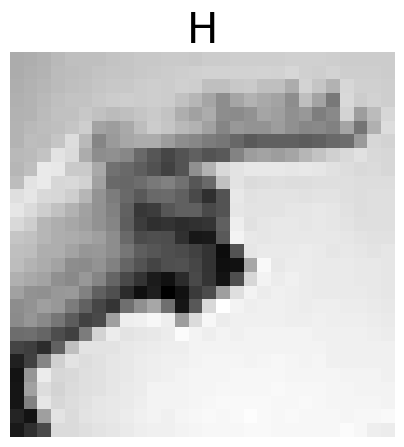

In [8]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [9]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [10]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [11]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well. 

In [12]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [13]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [14]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### Baseline model - fully connected network

Before we implement the CNN, let's train a simple fully connected neural network (FCNN) as a baseline. This will help us understand the performance improvement that the CNN architecture provides for image data.

In [15]:
model_fcnn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512),
    nn.ReLU(),
    nn.Dropout(.3),

    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_fcnn = model_fcnn.to(device)

In [16]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_fcnn.parameters())

fcnn_res = train(model_fcnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [00:14<00:00,  1.38epoch/s, train_acc=0.8997, train_loss=0.2861, val_acc=0.7922, val_loss=0.7890]


In [17]:
fcnn_test_loss, fcnn_test_acc = test(model_fcnn, test_loader, loss_function)

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [18]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 28 x 28
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 14 x 14
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [19]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [00:21<00:00,  1.10s/epoch, train_acc=0.9960, train_loss=0.0139, val_acc=0.9590, val_loss=0.2041]


In [20]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

## Reflection section

### Which model is better at classifying ASL images?

El modelo CNN clasifica a una imagenes de lengua de signos estadounidense mejor que el FCNN por la exactitud de validación de 95.90% y la pérdida de validación de 0.2041. 

### Which model was _faster_ to train?

El modelo FCNN se entrena 7 segundos más rápido que el CNN.

### Plot and compare the learning curves of both models. What do you observe about their training and validation performance over epochs?

El modelo CNN tiene una pérdida de entrenamiento mínima (después de la época 5), lo cual indica que las características espaciales son suficientemente efectivas para extraer los patrones de los datos de imágenes, mientras que la pérdida de validación se mantiene plana y fluctúa. Desafortunadamente, en el modelo FCNN, la pérdida decrece más despacio que la del CNN debido a la capa nn.Linear después de nn.Flatten, lo cual significa que pierde todo el contexto espacial al tratar cada píxel como una característica independiente. Después de la época 13, la pérdida de validación crece, volviéndose más alta que la del CNN. El modelo FCNN también pierde la capacidad de generalizar a nuevos datos. Por lo tanto, el CNN es superior al FCNN.

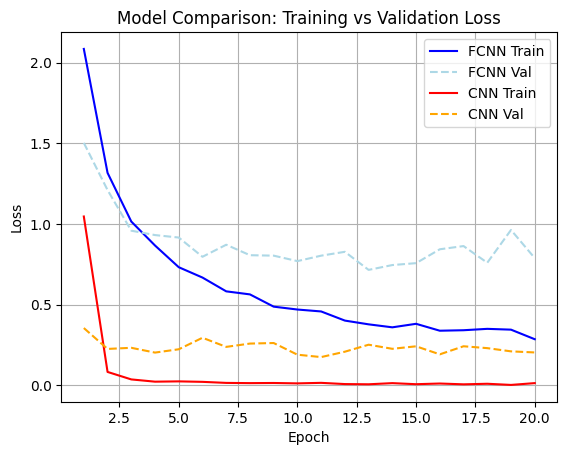

In [34]:
epochs = 20

fcnn_train_losses = fcnn_res["train_loss"]
fcnn_val_losses = fcnn_res["val_loss"]

cnn_train_losses = cnn_res["train_loss"]
cnn_val_losses = cnn_res["val_loss"]

range_epochs = range(1, epochs + 1)

# FCNN Model Plotting 
plt.plot(range_epochs, fcnn_train_losses, label="FCNN Train", color='blue', linestyle='-')
plt.plot(range_epochs, fcnn_val_losses, label="FCNN Val", color='lightblue', linestyle='--')

# CNN Model Plotting
plt.plot(range_epochs, cnn_train_losses, label="CNN Train", color='red', linestyle='-')
plt.plot(range_epochs, cnn_val_losses, label="CNN Val", color='orange', linestyle='--')

# Formatting
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Comparison: Training vs Validation Loss")
plt.legend() 
plt.grid(True)
plt.show()

### How many trainable parameters does each model have?

Remember that each convolutional layer has $K \times (C_{in} \times k_h \times k_w + 1)$ parameters, where $K$ is the number of filters, $C_{in}$ is the number of input channels, $k_h$ and $k_w$ are the kernel height and width, and the +1 accounts for the bias term.

Each fully connected layer has $N_{in} \times N_{out} + N_{out}$ parameters, where $N_{in}$ is the number of input features and $N_{out}$ is the number of output features.

Fully Connected Neural Network (FCNN):
- Primera Capa Lineal (`nn.Linear(28 * 28, 512)`):

  $N_{in} = 28 * 28 = 784$, $N_{out} = 512$

  $Capa_1 = 784 * 512 + 512 = 401408 + 512 = 401920$

- Segunda Capa Lineal (`nn.Linear(512, 512)`):

  $N_{in} = 512$, $N_{out} = 512$

  $Capa_2 = 512 * 512 + 512 = 262144 + 512 = 262656$

- Tercera Capa Lineal (`nn.Linear(512, 24)`)

  $N_{in} = 512$, $N_{out} = 24$

  $Capa_3 = 512 * 24 + 24 = 12288 + 24 = 12312$

- Parámetros en total $ = 401920 + 262656 + 12312 = 676888$



Convolutional Neural Network (CNN):
- Primera Capa Conv2d (`nn.Conv2d(1, 25, 3)`):

  $K = 25$, $C_{in}=1$  $k_{h} = 3$, $k_{w} = 3$

  $Capa_1 = 25 \times (1 \times 3 \times 3 + 1) = 25 \times (9 + 1) = 25 \times 10 = 250$

- Segunda Capa Conv2d (`nn.Conv2d(25, 50, 3)`):

  $K = 50$, $C_{in}=25$  $k_{h} = 3$, $k_{w} = 3$

  $Capa_2 = 50 \times (25 \times 3 \times 3 + 1) = 50 \times (225 + 1) = 50 \times 226 = 11300$

- Tercera Capa Conv2d (`nn.Conv2d(50, 75, 3)`):

  $K = 75$, $C_{in}=50$  $k_{h} = 3$, $k_{w} = 3$

  $Capa_3 = 75 \times (50 \times 3 \times 3 + 1) = 75 \times (450 + 1) = 75 \times 451 = 33825$

- Primera Capa Lineal (`nn.Linear(75 * 3 * 3, 512)`)

  $N_{in} = 75 * 3 * 3 = 675$, $N_{out} = 512$

  $Capa_4 = 675 * 512 + 512 = 345600 + 512 = 346112$

- Segunda Capa Lineal (`nn.Linear(512, 24)`)

  $N_{in} = 512$, $N_{out} = 24$

  $Capa_5 = 512 * 24 + 24 = 12288 + 24 = 12312$

- Parámetros en total $ = 250 + 11300 + 33825 + 346112 + 12312 = 403799$

### How do the models compare in terms of overfitting? Why do you think that is the case?

Para comparar el overfitting entre distintos modelos utilizando las curvas de aprendizaje, debemos analizar la evolución de la pérdida (loss) entre modelos observando la brecha entre la pérdida de entrenamiento (train loss) y la de validación (val loss). La brecha sirve como un indicador directo de overfitting; una brecha grande o creciente es una señal crítica de que el modelo está memorizando en lugar de generalizar.

### Final conclusions and remarks

Me parece que las Redes Neuronales Convolucionales (CNN) son una arquitectura muy interesante; destacan por su capacidad para mitigar el overfitting y mejorar la generalización en datos de imágenes, optimizando así el rendimiento del modelo. Además, suelen requerir menos épocas de entrenamiento que las redes totalmente conectadas (Fully Connected).

También considero que las redes neuronales convolucionales requieren menos parámetros, pero suelen estructurarse con una mayor profundidad (más capas) para extraer características jerárquicas, logrando así un mejor desempeño que las redes totalmente conectadas.